In [1]:
# =============================================================================
#        CLASIFICACION CON K-VECINOS CERCANOS (K-NN)
#        Dataset: ENDES 2024 - Modulo RECH6 (Anemia Infantil)
#        Objetivo: Clasificar ninos como Con Anemia o Sin Anemia
# =============================================================================

# --- LIBRERIAS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_score,
    recall_score, f1_score
)

# Configuracion visual global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
PALETTE = ['#2196F3', '#E91E63']   # 0 = Sin Anemia (azul) | 1 = Anemia (rosa)
SEPARADOR = "=" * 65
RANDOM_STATE = 123   # semilla fijada segun la metodologia del curso

In [2]:
# =============================================================================
# 1. IMPORTAR Y CARGAR LOS DATOS
# =============================================================================
print(SEPARADOR)
print("  1. CARGA DE DATOS")
print(SEPARADOR)

# En Colab: si el archivo no esta en el entorno, se solicita su carga manual
import os
RUTA_ARCHIVO = 'RECH6_2024.xlsx'

if not os.path.exists(RUTA_ARCHIVO):
    from google.colab import files
    print("Sube el archivo 'RECH6_2024.xlsx' cuando se abra el dialogo...")
    subido = files.upload()
    RUTA_ARCHIVO = list(subido.keys())[0]

raw = pd.read_excel(RUTA_ARCHIVO)
print(f"Archivo cargado: {RUTA_ARCHIVO}  ->  {raw.shape[0]} filas, {raw.shape[1]} columnas")

# --- Seleccion y filtrado segun el diccionario RECH6 ---
# HC55 == 0  -> hemoglobina fue efectivamente medida
# HC57A en {1,2,3,4} -> nivel de anemia valido (Nueva Directriz OMS 2024)
# HC70, HC71, HC72, HC73 -> puntuaciones Z (OMS); se descartan codigos >= 9000
#   (9996 fuera de limites plausibles, 9997 edad fuera de limites, 9998/9999 casos marcados)
cols_z = ['HC70', 'HC71', 'HC72', 'HC73']

mask = (raw['HC55'] == 0) & (raw['HC57A'].isin([1, 2, 3, 4]))
for c in cols_z:
    mask &= (raw[c] < 9000)

datos = raw.loc[mask, ['HC1', 'HC70', 'HC71', 'HC72', 'HC73', 'HC57A']].copy()

# --- Construccion de variables (division entre 100: los Z-scores vienen con 2 decimales implicitos) ---
datos = datos.rename(columns={'HC1': 'edad_meses'})
datos['talla_edad_z'] = datos['HC70'] / 100
datos['peso_edad_z']  = datos['HC71'] / 100
datos['peso_talla_z'] = datos['HC72'] / 100
datos['imc_z']        = datos['HC73'] / 100
datos = datos.drop(columns=cols_z)

# --- Variable objetivo: anemia (1,2,3 = Leve/Moderada/Grave) vs sin anemia (4) ---
# Nota: la hemoglobina (HC53/HC55/HC56/HC56A/HC57) se excluye deliberadamente de los
# predictores para evitar circularidad, ya que es la variable con la que se define el target.
datos['target'] = datos['HC57A'].isin([1, 2, 3]).astype(int)
datos['diagnostico'] = datos['target'].map({0: 'Sin Anemia', 1: 'Anemia'})
datos = datos.drop(columns=['HC57A'])

df = datos.reset_index(drop=True)
predictores = ['edad_meses', 'talla_edad_z', 'peso_edad_z', 'peso_talla_z', 'imc_z']

print(f"\nDataset final tras filtrado: {df.shape[0]} ninos, {len(predictores)} predictores")
print(f"Predictores  : {predictores}")
print(f"Clases       : ['Sin Anemia', 'Anemia']")
print("\nPrimeras 5 filas:")
print(df.head())

  1. CARGA DE DATOS
Archivo cargado: RECH6_2024.xlsx  ->  20290 filas, 43 columnas

Dataset final tras filtrado: 18306 ninos, 5 predictores
Predictores  : ['edad_meses', 'talla_edad_z', 'peso_edad_z', 'peso_talla_z', 'imc_z']
Clases       : ['Sin Anemia', 'Anemia']

Primeras 5 filas:
   edad_meses  talla_edad_z  peso_edad_z  peso_talla_z  imc_z  target  \
0          43         -0.88        -0.10          0.60   0.64       0   
1          13         -1.67        -0.17          0.81   1.11       0   
2          19         -0.78         0.91          1.75   1.90       0   
3          13         -0.27         0.67          1.04   1.12       1   
4          18         -1.19         0.13          0.93   1.19       0   

  diagnostico  
0  Sin Anemia  
1  Sin Anemia  
2  Sin Anemia  
3      Anemia  
4  Sin Anemia  


In [3]:
# =============================================================================
# 2. VALORES AUSENTES
# =============================================================================
print(f"\n{SEPARADOR}")
print("  2. VALORES AUSENTES")
print(SEPARADOR)

ausentes = df.isnull().sum()
pct_ausentes = (df.isnull().mean() * 100).round(2)
resumen_nulos = pd.DataFrame({
    'Valores Ausentes': ausentes,
    'Porcentaje (%)': pct_ausentes
})
print(resumen_nulos[resumen_nulos['Valores Ausentes'] > 0])

if ausentes.sum() == 0:
    print("No se encontraron valores ausentes en el dataset (ya filtrado segun el diccionario RECH6).")
else:
    print(f"\nTotal de valores ausentes: {ausentes.sum()}")
    df.fillna(df.median(numeric_only=True), inplace=True)
    print("Valores ausentes imputados con la mediana.")


  2. VALORES AUSENTES
Empty DataFrame
Columns: [Valores Ausentes, Porcentaje (%)]
Index: []
No se encontraron valores ausentes en el dataset (ya filtrado segun el diccionario RECH6).


In [4]:
# =============================================================================
# 3. TIPOS DE VARIABLES
# =============================================================================
print(f"\n{SEPARADOR}")
print("  3. TIPOS DE VARIABLES")
print(SEPARADOR)

tipos = pd.DataFrame({
    'Tipo de Dato'      : df.dtypes,
    'Categoria'         : df.dtypes.apply(
        lambda x: 'Cuantitativa' if pd.api.types.is_numeric_dtype(x) else 'Cualitativa'
    ),
    'Valores Unicos'    : df.nunique()
})
print(tipos)
print(f"\nVariables numericas  : {df.select_dtypes(include=np.number).shape[1]}")
print(f"Variables categoricas: {df.select_dtypes(exclude=np.number).shape[1]}")


  3. TIPOS DE VARIABLES
             Tipo de Dato     Categoria  Valores Unicos
edad_meses          int64  Cuantitativa              54
talla_edad_z      float64  Cuantitativa             651
peso_edad_z       float64  Cuantitativa             700
peso_talla_z      float64  Cuantitativa             701
imc_z             float64  Cuantitativa             695
target              int64  Cuantitativa               2
diagnostico        object   Cualitativa               2

Variables numericas  : 6
Variables categoricas: 1


In [5]:
# =============================================================================
# 4. ESTADISTICA DESCRIPTIVA
# =============================================================================
print(f"\n{SEPARADOR}")
print("  4. ESTADISTICA DESCRIPTIVA")
print(SEPARADOR)

desc = df[predictores + ['target']].describe().T
desc['rango'] = desc['max'] - desc['min']
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)
print(desc[['mean', 'std', 'min', '50%', 'max', 'rango', 'CV (%)']].round(3))


  4. ESTADISTICA DESCRIPTIVA
                mean     std   min    50%    max  rango  CV (%)
edad_meses    32.530  15.604  6.00  33.00  59.00  53.00   47.97
talla_edad_z  -0.878   1.013 -5.51  -0.88   3.54   9.05 -115.36
peso_edad_z   -0.142   1.040 -4.54  -0.18   4.43   8.97 -730.44
peso_talla_z   0.480   1.010 -4.74   0.44   4.92   9.66  210.26
imc_z          0.576   0.992 -4.87   0.54   4.97   9.84  172.31
target         0.314   0.464  0.00   0.00   1.00   1.00  147.70



  5. VISUALIZACION SEGUN VARIABLE DEPENDIENTE


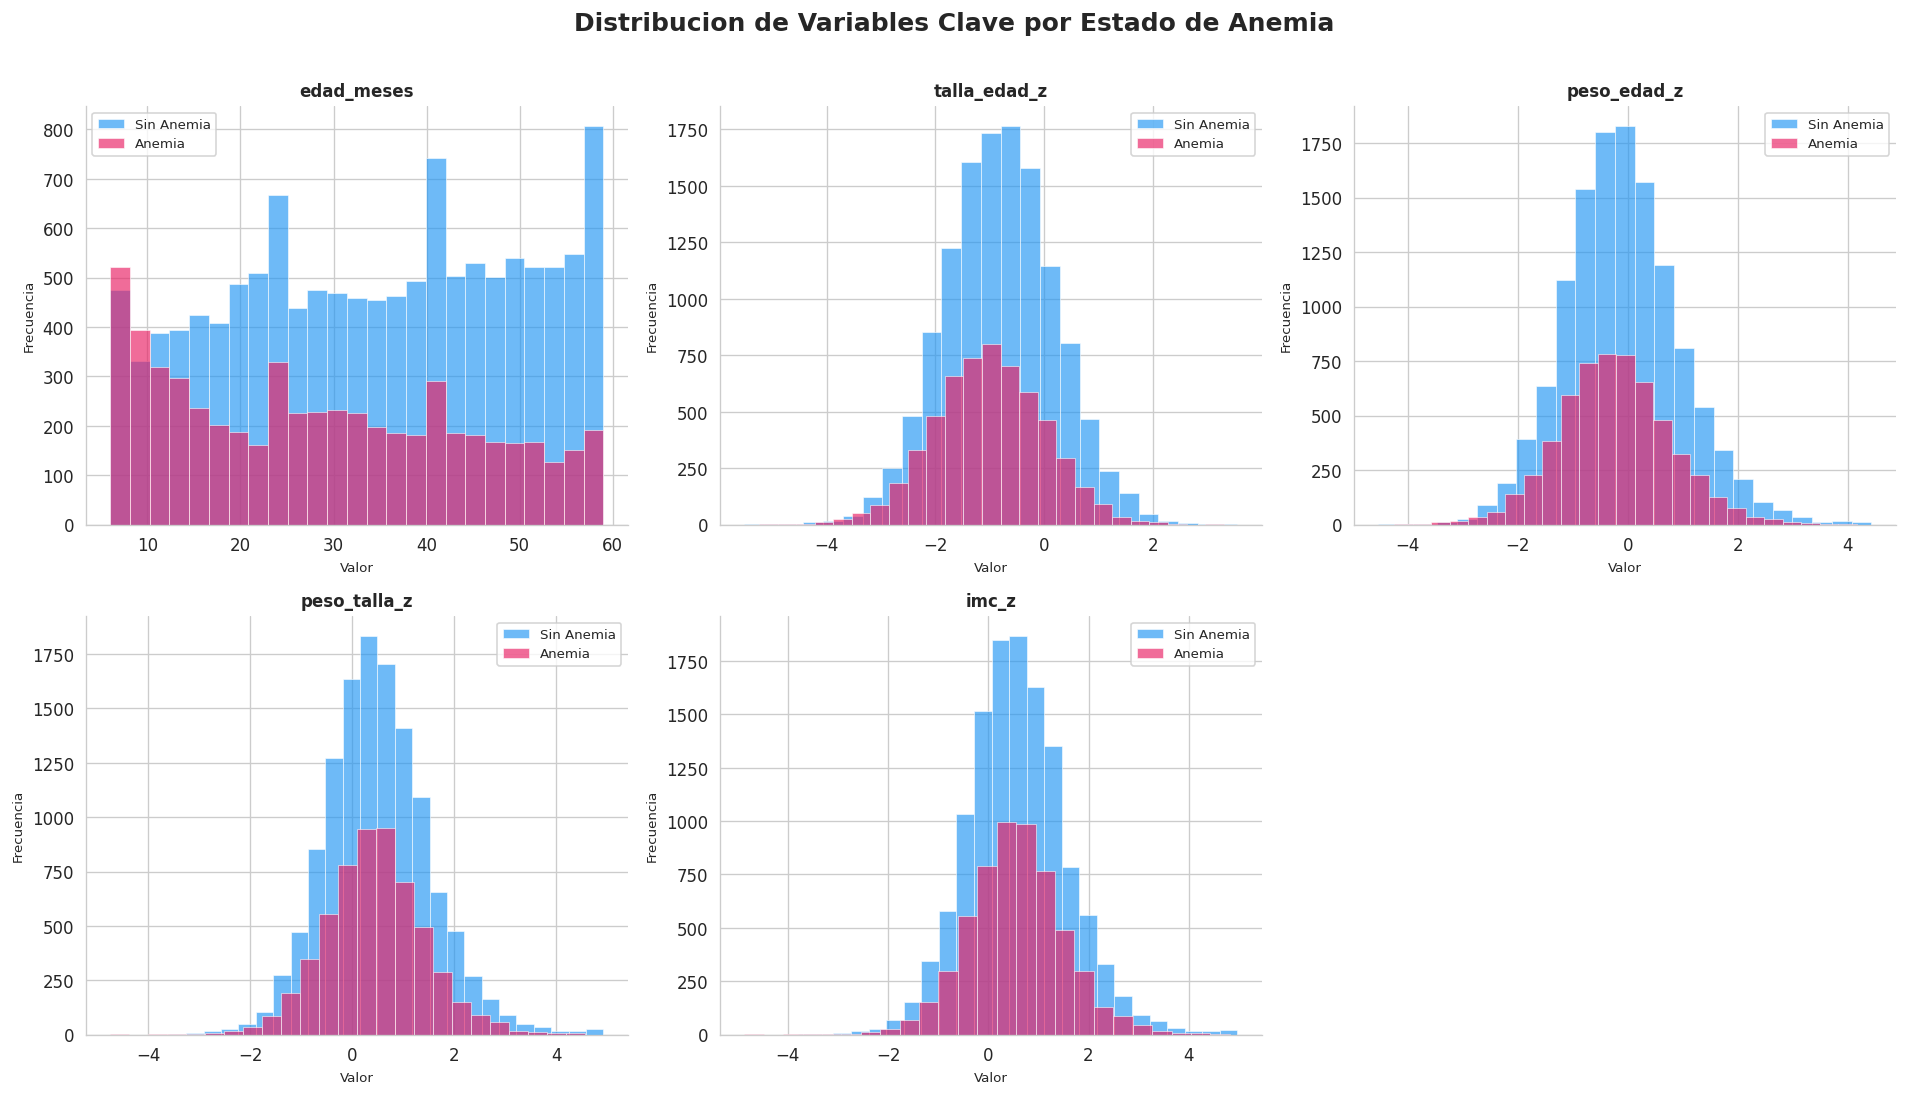

Grafico guardado: 05_distribucion_por_target.png


In [6]:
# =============================================================================
# 5. VISUALIZACION SEGUN LA VARIABLE DEPENDIENTE (Target)
# =============================================================================
print(f"\n{SEPARADOR}")
print("  5. VISUALIZACION SEGUN VARIABLE DEPENDIENTE")
print(SEPARADOR)

features_viz = predictores  # las 5 variables cuantitativas del estudio

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribucion de Variables Clave por Estado de Anemia', fontsize=15, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flatten(), features_viz):
    for diag, color in zip(['Sin Anemia', 'Anemia'], PALETTE):
        datos_f = df[df['diagnostico'] == diag][feat]
        ax.hist(datos_f, bins=25, alpha=0.65, color=color, label=diag, edgecolor='white', linewidth=0.5)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Ocultar el ultimo subplot vacio (5 variables en grilla de 6)
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.savefig('05_distribucion_por_target.png', bbox_inches='tight')
plt.show()
print("Grafico guardado: 05_distribucion_por_target.png")


  6. HISTOGRAMAS DE VARIABLES NUMERICAS


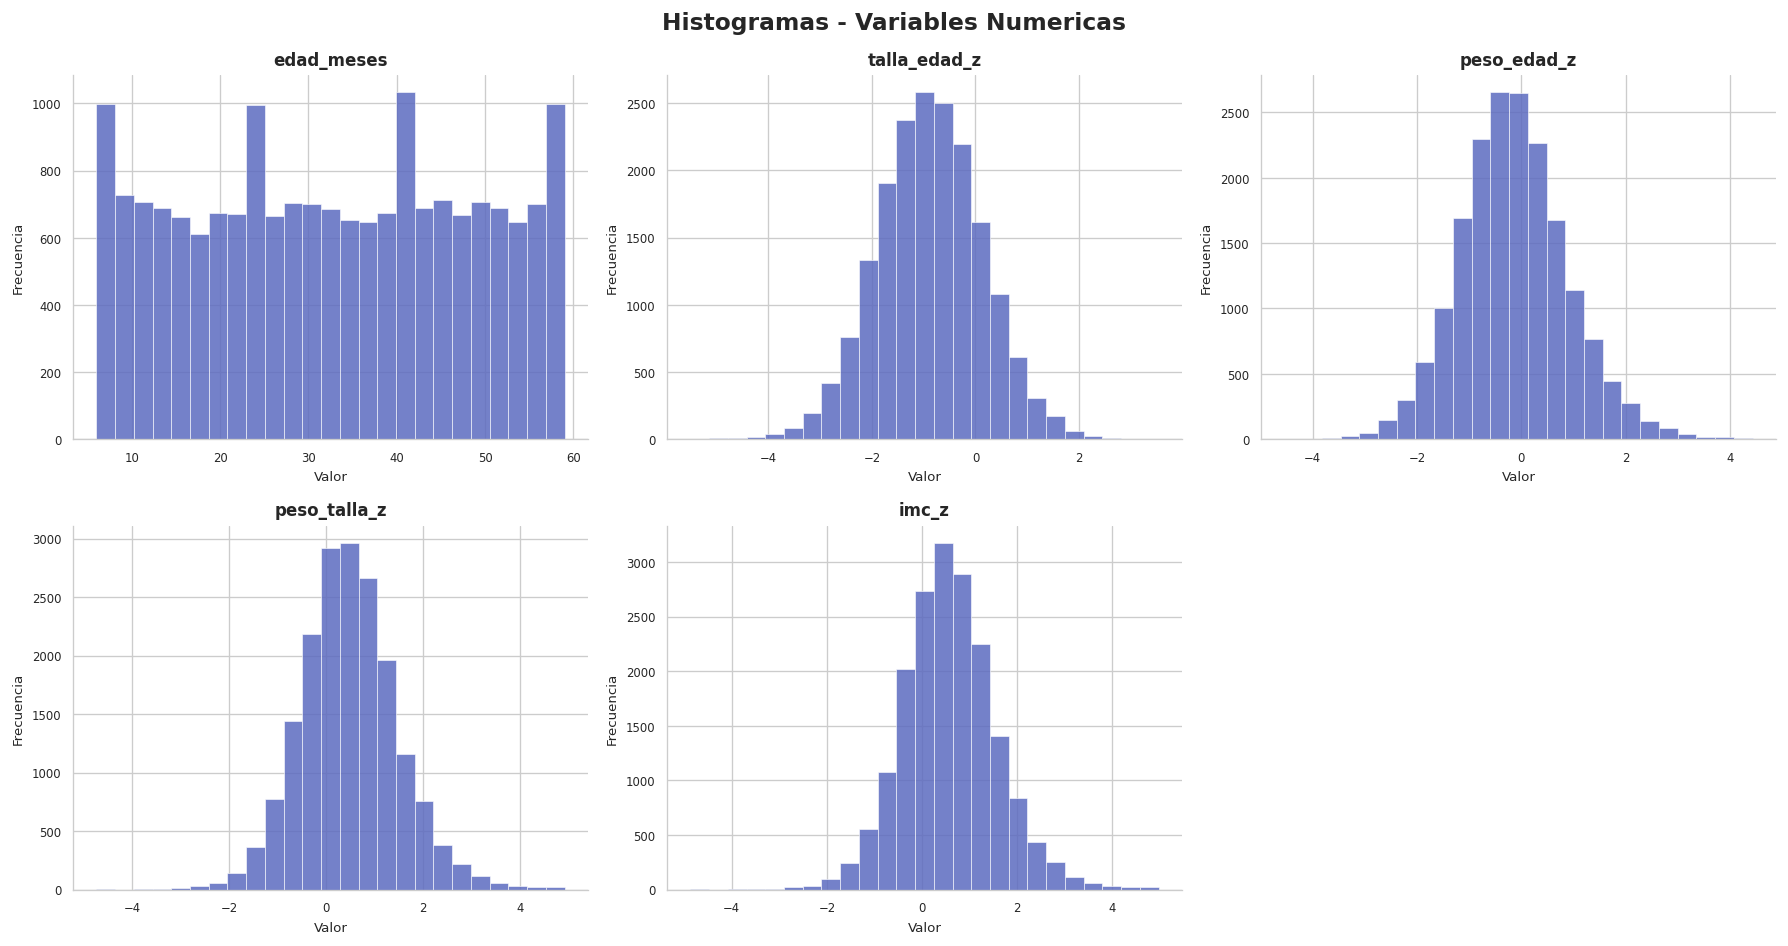

Grafico guardado: 06_histogramas.png


In [7]:
# =============================================================================
# 6. HISTOGRAMAS DE TODAS LAS VARIABLES
# =============================================================================
print(f"\n{SEPARADOR}")
print("  6. HISTOGRAMAS DE VARIABLES NUMERICAS")
print(SEPARADOR)

cols_num = predictores
n_cols = 3
n_rows = int(np.ceil(len(cols_num) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
fig.suptitle('Histogramas - Variables Numericas', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cols_num):
    ax.hist(df[col], bins=25, color='#5C6BC0', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes.flatten()[len(cols_num):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('06_histogramas.png', bbox_inches='tight')
plt.show()
print("Grafico guardado: 06_histogramas.png")


  7. TABLA DE DISTRIBUCION DEL TARGET
Diagnostico  Frecuencia  Porcentaje (%)
 Sin Anemia       12552           68.57
     Anemia        5754           31.43


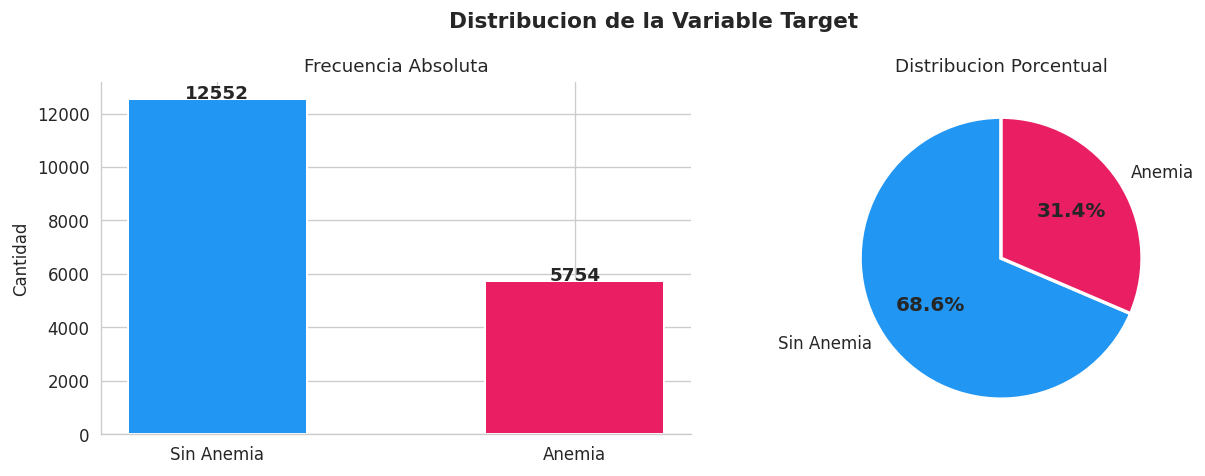

In [8]:
# =============================================================================
# 7. TABLA DE DISTRIBUCION DEL TARGET
# =============================================================================
print(f"\n{SEPARADOR}")
print("  7. TABLA DE DISTRIBUCION DEL TARGET")
print(SEPARADOR)

tabla_target = df['diagnostico'].value_counts().reset_index()
tabla_target.columns = ['Diagnostico', 'Frecuencia']
tabla_target['Porcentaje (%)'] = (tabla_target['Frecuencia'] / len(df) * 100).round(2)
print(tabla_target.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Distribucion de la Variable Target', fontsize=13, fontweight='bold')

axes[0].bar(tabla_target['Diagnostico'], tabla_target['Frecuencia'],
            color=PALETTE, edgecolor='white', linewidth=1.2, width=0.5)
for i, v in enumerate(tabla_target['Frecuencia']):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Frecuencia Absoluta', fontsize=11)
axes[0].set_ylabel('Cantidad')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

wedges, texts, autotexts = axes[1].pie(
    tabla_target['Frecuencia'],
    labels=tabla_target['Diagnostico'],
    autopct='%1.1f%%',
    colors=PALETTE,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
axes[1].set_title('Distribucion Porcentual', fontsize=11)

plt.tight_layout()
plt.savefig('07_tabla_target.png', bbox_inches='tight')
plt.show()


  8. CORRELACION ENTRE VARIABLES


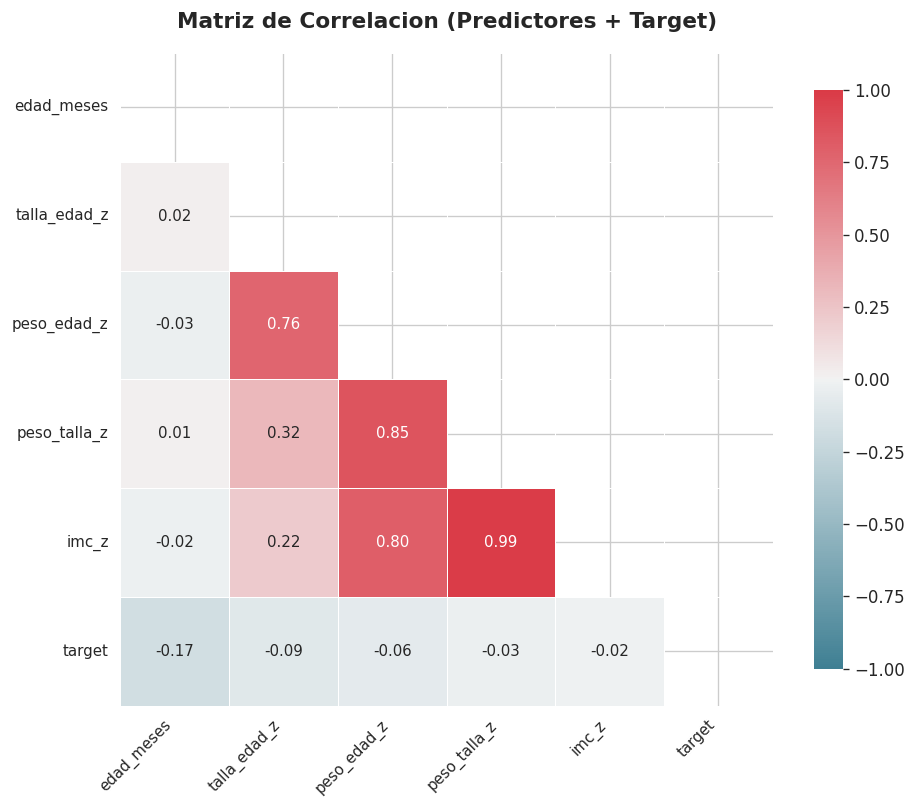


Correlacion de cada predictor con el TARGET:
              Correlacion |r|
edad_meses             0.1735
talla_edad_z           0.0925
peso_edad_z            0.0627
peso_talla_z           0.0260
imc_z                  0.0151


In [9]:
# =============================================================================
# 8. MATRIZ DE CORRELACION
# =============================================================================
print(f"\n{SEPARADOR}")
print("  8. CORRELACION ENTRE VARIABLES")
print(SEPARADOR)

cols_corr = predictores + ['target']
corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask_tri = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    corr_matrix, mask=mask_tri, cmap=cmap, center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    annot_kws={'size': 9}, square=True, ax=ax,
    vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlacion (Predictores + Target)',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('08_correlacion.png', bbox_inches='tight')
plt.show()

print("\nCorrelacion de cada predictor con el TARGET:")
corr_target = df[predictores].corrwith(df['target']).abs().sort_values(ascending=False)
print(corr_target.to_frame('Correlacion |r|').round(4))


  9. DOS VARIABLES CUANTITATIVAS VS. TARGET
Variables seleccionadas: edad_meses  |  talla_edad_z


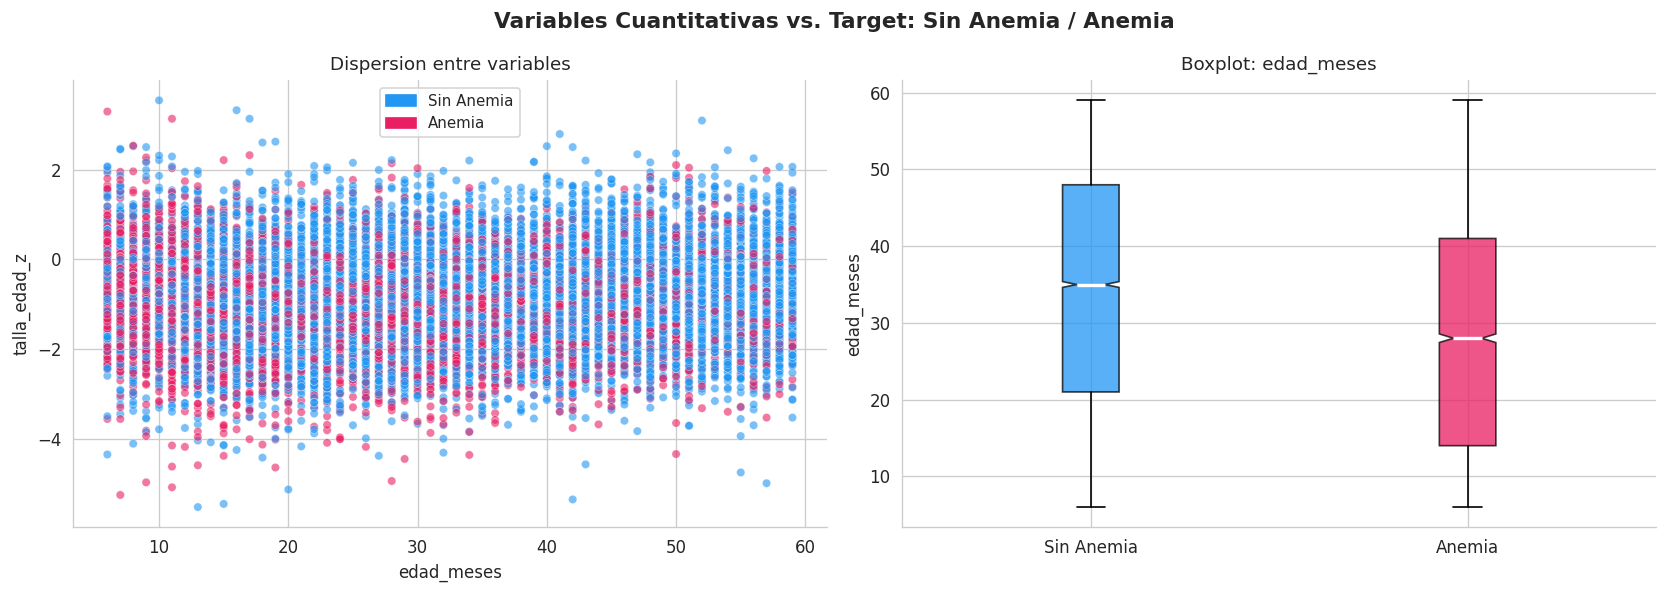

In [10]:
# =============================================================================
# 9. DOS VARIABLES CUANTITATIVAS vs. TARGET (Scatter Plot)
# =============================================================================
print(f"\n{SEPARADOR}")
print("  9. DOS VARIABLES CUANTITATIVAS VS. TARGET")
print(SEPARADOR)

top2 = corr_target.head(2).index.tolist()
print(f"Variables seleccionadas: {top2[0]}  |  {top2[1]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Variables Cuantitativas vs. Target: Sin Anemia / Anemia',
             fontsize=13, fontweight='bold')

colores_target = df['target'].map({0: PALETTE[0], 1: PALETTE[1]})

scatter = axes[0].scatter(
    df[top2[0]], df[top2[1]],
    c=colores_target, alpha=0.6, s=25, edgecolors='white', linewidth=0.3
)
axes[0].set_xlabel(top2[0], fontsize=10)
axes[0].set_ylabel(top2[1], fontsize=10)
axes[0].set_title('Dispersion entre variables', fontsize=11)
from matplotlib.patches import Patch
leyenda = [Patch(color=PALETTE[0], label='Sin Anemia'),
           Patch(color=PALETTE[1], label='Anemia')]
axes[0].legend(handles=leyenda, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

data_box = [
    df[df['diagnostico'] == 'Sin Anemia'][top2[0]].values,
    df[df['diagnostico'] == 'Anemia'][top2[0]].values
]
bp = axes[1].boxplot(data_box, patch_artist=True, notch=True,
                     labels=['Sin Anemia', 'Anemia'],
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title(f'Boxplot: {top2[0]}', fontsize=11)
axes[1].set_ylabel(top2[0], fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('09_scatter_target.png', bbox_inches='tight')
plt.show()


  10. MODELO KNN: SIN Y CON CROSS-VALIDATION

--- A) MODELO KNN SIN CROSS-VALIDATION (k=5) ---
Precision en entrenamiento : 0.7455
Precision en prueba        : 0.6528

--- B) MODELO KNN CON CROSS-VALIDATION (k=5, cv=10) ---
Scores por fold : [0.6286 0.6235 0.6315 0.657  0.6431 0.6489 0.6315 0.6431 0.6606 0.6195]
Media CV        : 0.6387
Desv. Estandar  : 0.0133
Intervalo 95%   : [0.6122, 0.6653]


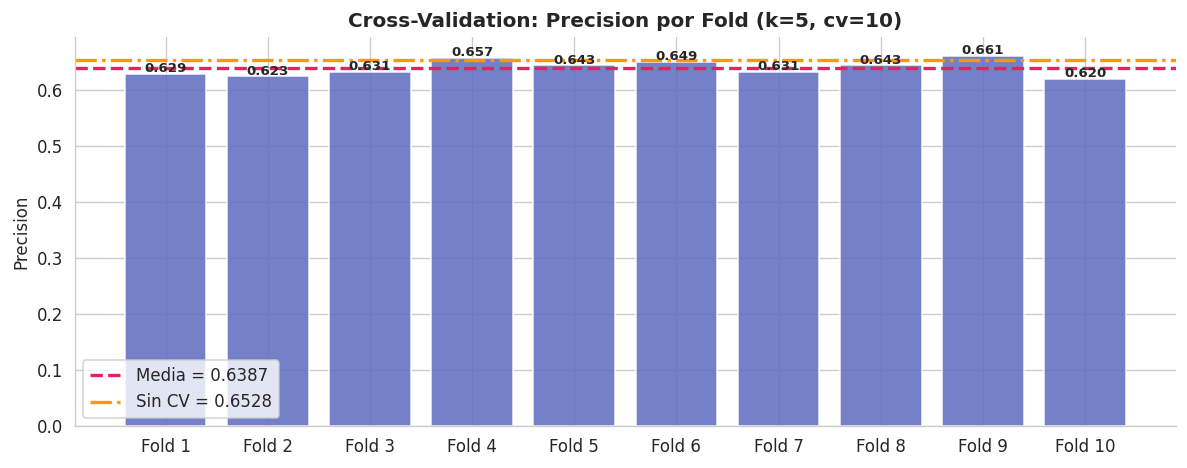

In [11]:
# =============================================================================
# 10. MODELO KNN: SIN y CON CROSS-VALIDATION
# =============================================================================
print(f"\n{SEPARADOR}")
print("  10. MODELO KNN: SIN Y CON CROSS-VALIDATION")
print(SEPARADOR)

# --- Preparacion de datos ---
X = df[predictores]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --- Modelo SIN Cross-Validation ---
print("\n--- A) MODELO KNN SIN CROSS-VALIDATION (k=5) ---")
knn_simple = KNeighborsClassifier(n_neighbors=5)
knn_simple.fit(X_train_sc, y_train)
y_pred_simple = knn_simple.predict(X_test_sc)

acc_simple = accuracy_score(y_test, y_pred_simple)
print(f"Precision en entrenamiento : {knn_simple.score(X_train_sc, y_train):.4f}")
print(f"Precision en prueba        : {acc_simple:.4f}")

# --- Modelo CON Cross-Validation ---
print("\n--- B) MODELO KNN CON CROSS-VALIDATION (k=5, cv=10) ---")
knn_cv = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(knn_cv, X_train_sc, y_train, cv=10, scoring='accuracy')

print(f"Scores por fold : {np.round(cv_scores, 4)}")
print(f"Media CV        : {cv_scores.mean():.4f}")
print(f"Desv. Estandar  : {cv_scores.std():.4f}")
print(f"Intervalo 95%   : [{cv_scores.mean() - 2*cv_scores.std():.4f},"
      f" {cv_scores.mean() + 2*cv_scores.std():.4f}]")

fig, ax = plt.subplots(figsize=(10, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars = ax.bar(folds, cv_scores, color='#5C6BC0', edgecolor='white', linewidth=1, alpha=0.85)
ax.axhline(cv_scores.mean(), color='#E91E63', linewidth=2, linestyle='--',
           label=f'Media = {cv_scores.mean():.4f}')
ax.axhline(acc_simple, color='#FF9800', linewidth=2, linestyle='-.',
           label=f'Sin CV = {acc_simple:.4f}')
for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{score:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.set_title('Cross-Validation: Precision por Fold (k=5, cv=10)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('10_cross_validation.png', bbox_inches='tight')
plt.show()


  11. MATRIZ DE CONFUSION
Verdaderos Negativos (TN) - Sin Anemia correcto : 2610
Falsos Positivos     (FP) - Sin Anemia como Anemia: 528
Falsos Negativos     (FN) - Anemia como Sin Anemia: 1061
Verdaderos Positivos (TP) - Anemia correcto     : 378


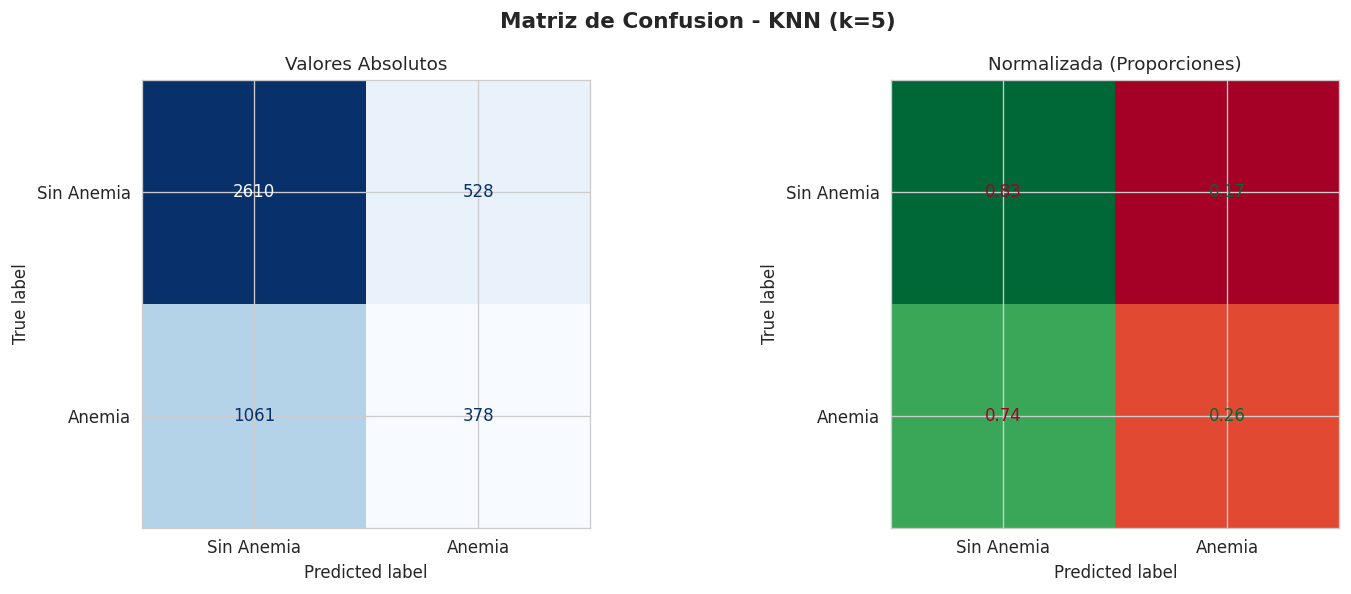

In [12]:
# =============================================================================
# 11. MATRIZ DE CONFUSION
# =============================================================================
print(f"\n{SEPARADOR}")
print("  11. MATRIZ DE CONFUSION")
print(SEPARADOR)

cm = confusion_matrix(y_test, y_pred_simple)
tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN) - Sin Anemia correcto : {tn}")
print(f"Falsos Positivos     (FP) - Sin Anemia como Anemia: {fp}")
print(f"Falsos Negativos     (FN) - Anemia como Sin Anemia: {fn}")
print(f"Verdaderos Positivos (TP) - Anemia correcto     : {tp}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matriz de Confusion - KNN (k=5)', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_simple,
    display_labels=['Sin Anemia', 'Anemia'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Valores Absolutos', fontsize=11)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_simple,
    display_labels=['Sin Anemia', 'Anemia'],
    cmap='RdYlGn', normalize='true', ax=axes[1], colorbar=False
)
axes[1].set_title('Normalizada (Proporciones)', fontsize=11)

plt.tight_layout()
plt.savefig('11_matriz_confusion.png', bbox_inches='tight')
plt.show()

In [13]:
# =============================================================================
# 12. PRECISION DEL MODELO Y METRICAS COMPLETAS
# =============================================================================
print(f"\n{SEPARADOR}")
print("  12. PRECISION GENERAL DEL MODELO")
print(SEPARADOR)

train_acc = knn_simple.score(X_train_sc, y_train)
test_acc  = accuracy_score(y_test, y_pred_simple)

print(f"Precision entrenamiento : {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"Precision prueba        : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Diferencia (Overfit?)   : {abs(train_acc - test_acc):.4f}")

if abs(train_acc - test_acc) > 0.05:
    print("Alerta: Posible sobreajuste detectado.")
else:
    print("Modelo generaliza bien (diferencia < 5%).")

print(f"\n{SEPARADOR}")
print("  METRICAS DETALLADAS")
print(SEPARADOR)

precision  = precision_score(y_test, y_pred_simple)
recall     = recall_score(y_test, y_pred_simple)
f1         = f1_score(y_test, y_pred_simple)
especif    = tn / (tn + fp)

print(f"Accuracy (Exactitud)    : {test_acc:.4f}")
print(f"Precision               : {precision:.4f}")
print(f"Recall (Sensibilidad)   : {recall:.4f}")
print(f"Especificidad           : {especif:.4f}")
print(f"F1-Score                : {f1:.4f}")
print(f"Falsa Tasa de Alarma    : {fp/(fp+tn):.4f}")
print(f"Tasa de Error           : {1 - test_acc:.4f}")

print("\nReporte completo (scikit-learn):")
print(classification_report(y_test, y_pred_simple, target_names=['Sin Anemia', 'Anemia']))


  12. PRECISION GENERAL DEL MODELO
Precision entrenamiento : 0.7455  (74.55%)
Precision prueba        : 0.6528  (65.28%)
Diferencia (Overfit?)   : 0.0927
Alerta: Posible sobreajuste detectado.

  METRICAS DETALLADAS
Accuracy (Exactitud)    : 0.6528
Precision               : 0.4172
Recall (Sensibilidad)   : 0.2627
Especificidad           : 0.8317
F1-Score                : 0.3224
Falsa Tasa de Alarma    : 0.1683
Tasa de Error           : 0.3472

Reporte completo (scikit-learn):
              precision    recall  f1-score   support

  Sin Anemia       0.71      0.83      0.77      3138
      Anemia       0.42      0.26      0.32      1439

    accuracy                           0.65      4577
   macro avg       0.56      0.55      0.54      4577
weighted avg       0.62      0.65      0.63      4577




  13. BUSQUEDA DEL K OPTIMO
Mejor k segun Test Set         : k = 24  (Acc = 0.6902)
Mejor k segun Cross-Validation : k = 30  (Acc = 0.6813)


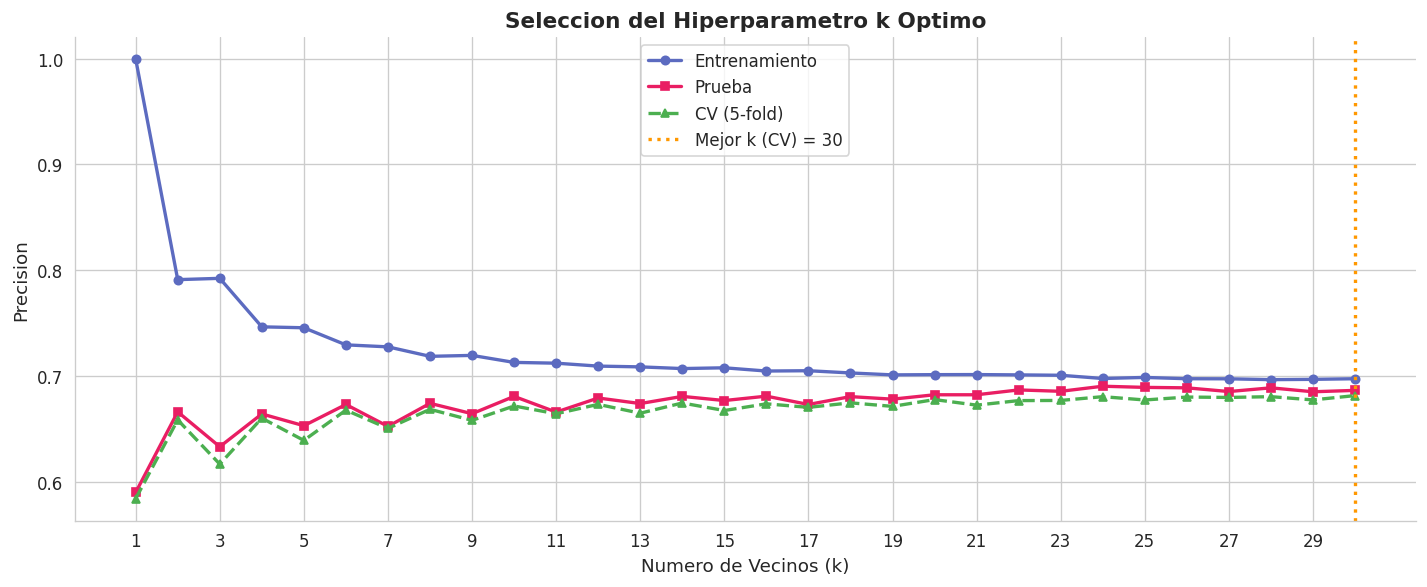

In [14]:
# =============================================================================
# 13. BUSQUEDA DEL K ADECUADO
# =============================================================================
print(f"\n{SEPARADOR}")
print("  13. BUSQUEDA DEL K OPTIMO")
print(SEPARADOR)

k_range    = range(1, 31)
train_accs = []
test_accs  = []
cv_medias  = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_sc, y_train)
    train_accs.append(knn_temp.score(X_train_sc, y_train))
    test_accs.append(accuracy_score(y_test, knn_temp.predict(X_test_sc)))
    cv_medias.append(cross_val_score(knn_temp, X_train_sc, y_train, cv=5).mean())

mejor_k_test = k_range[np.argmax(test_accs)]
mejor_k_cv   = k_range[np.argmax(cv_medias)]

print(f"Mejor k segun Test Set         : k = {mejor_k_test}  (Acc = {max(test_accs):.4f})")
print(f"Mejor k segun Cross-Validation : k = {mejor_k_cv}  (Acc = {max(cv_medias):.4f})")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_range, train_accs, 'o-', color='#5C6BC0', linewidth=2,
        markersize=5, label='Entrenamiento')
ax.plot(k_range, test_accs, 's-', color='#E91E63', linewidth=2,
        markersize=5, label='Prueba')
ax.plot(k_range, cv_medias, '^--', color='#4CAF50', linewidth=2,
        markersize=5, label='CV (5-fold)')
ax.axvline(mejor_k_cv, color='#FF9800', linewidth=2, linestyle=':',
           label=f'Mejor k (CV) = {mejor_k_cv}')
ax.set_xlabel('Numero de Vecinos (k)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Seleccion del Hiperparametro k Optimo', fontsize=13, fontweight='bold')
ax.set_xticks(list(k_range)[::2])
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('13_busqueda_k.png', bbox_inches='tight')
plt.show()

In [15]:
# =============================================================================
# 14. PROCEDIMIENTO COMPLETO CON MEJOR K Y GridSearchCV
# =============================================================================
print(f"\n{SEPARADOR}")
print("  14. PROCEDIMIENTO COMPLETO CON MEJOR K")
print(SEPARADOR)

param_grid = {
    'n_neighbors': np.arange(1, 31),
    'metric'     : ['euclidean', 'manhattan', 'chebyshev'],
    'weights'    : ['uniform', 'distance']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_sc, y_train)

print(f"Mejores parametros encontrados:")
for param, val in grid_search.best_params_.items():
    print(f"  {param:<20}: {val}")
print(f"\nMejor score en CV        : {grid_search.best_score_:.4f}")

knn_final    = grid_search.best_estimator_
y_pred_final = knn_final.predict(X_test_sc)
acc_final    = accuracy_score(y_test, y_pred_final)

print(f"Precision modelo final   : {acc_final:.4f}")
print(f"Mejora vs. k=5 inicial   : {(acc_final - test_acc)*100:+.2f}%")


  14. PROCEDIMIENTO COMPLETO CON MEJOR K
Mejores parametros encontrados:
  metric              : chebyshev
  n_neighbors         : 30
  weights             : uniform

Mejor score en CV        : 0.6814
Precision modelo final   : 0.6856
Mejora vs. k=5 inicial   : +3.28%



  15. PRECISION POR CLASE
            Precision  Recall  F1-Score  Soporte
Sin Anemia     0.7012  0.9436    0.8045     3138
Anemia         0.5000  0.1230    0.1974     1439


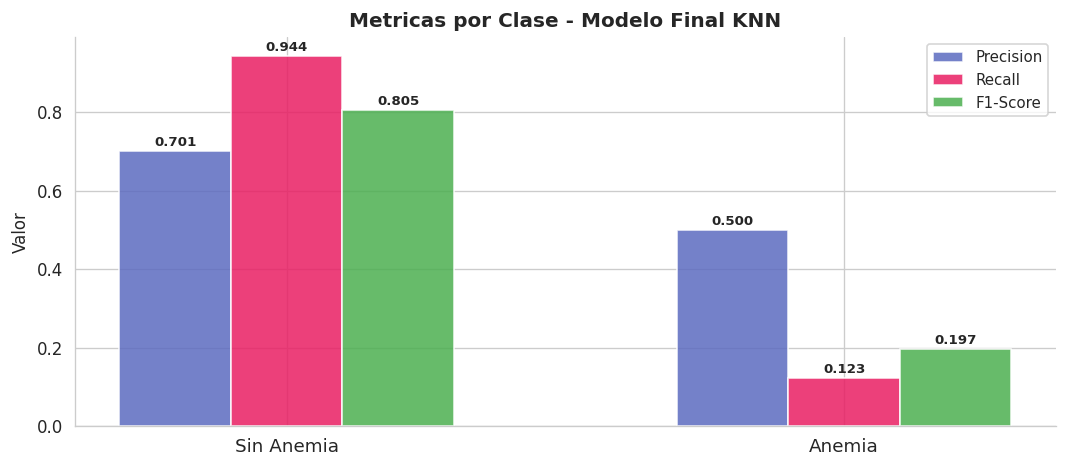

In [16]:
# =============================================================================
# 15. PRECISION POR CLASE
# =============================================================================
print(f"\n{SEPARADOR}")
print("  15. PRECISION POR CLASE")
print(SEPARADOR)

report_dict = classification_report(
    y_test, y_pred_final,
    target_names=['Sin Anemia', 'Anemia'],
    output_dict=True
)

metricas_clase = pd.DataFrame(report_dict).T.iloc[:2, :4]
metricas_clase.columns = ['Precision', 'Recall', 'F1-Score', 'Soporte']
metricas_clase['Soporte'] = metricas_clase['Soporte'].astype(int)
print(metricas_clase.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(2)
ancho = 0.2
metricas_plot = ['Precision', 'Recall', 'F1-Score']
colores_bar = ['#5C6BC0', '#E91E63', '#4CAF50']

for i, (metrica, color) in enumerate(zip(metricas_plot, colores_bar)):
    valores = metricas_clase[metrica].values
    bars = ax.bar(x + i * ancho, valores, ancho, label=metrica,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + ancho)
ax.set_xticklabels(['Sin Anemia', 'Anemia'], fontsize=11)
ax.set_title('Metricas por Clase - Modelo Final KNN', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('15_precision_por_clase.png', bbox_inches='tight')
plt.show()


  16. VISUALIZACION GENERAL DE RESULTADOS


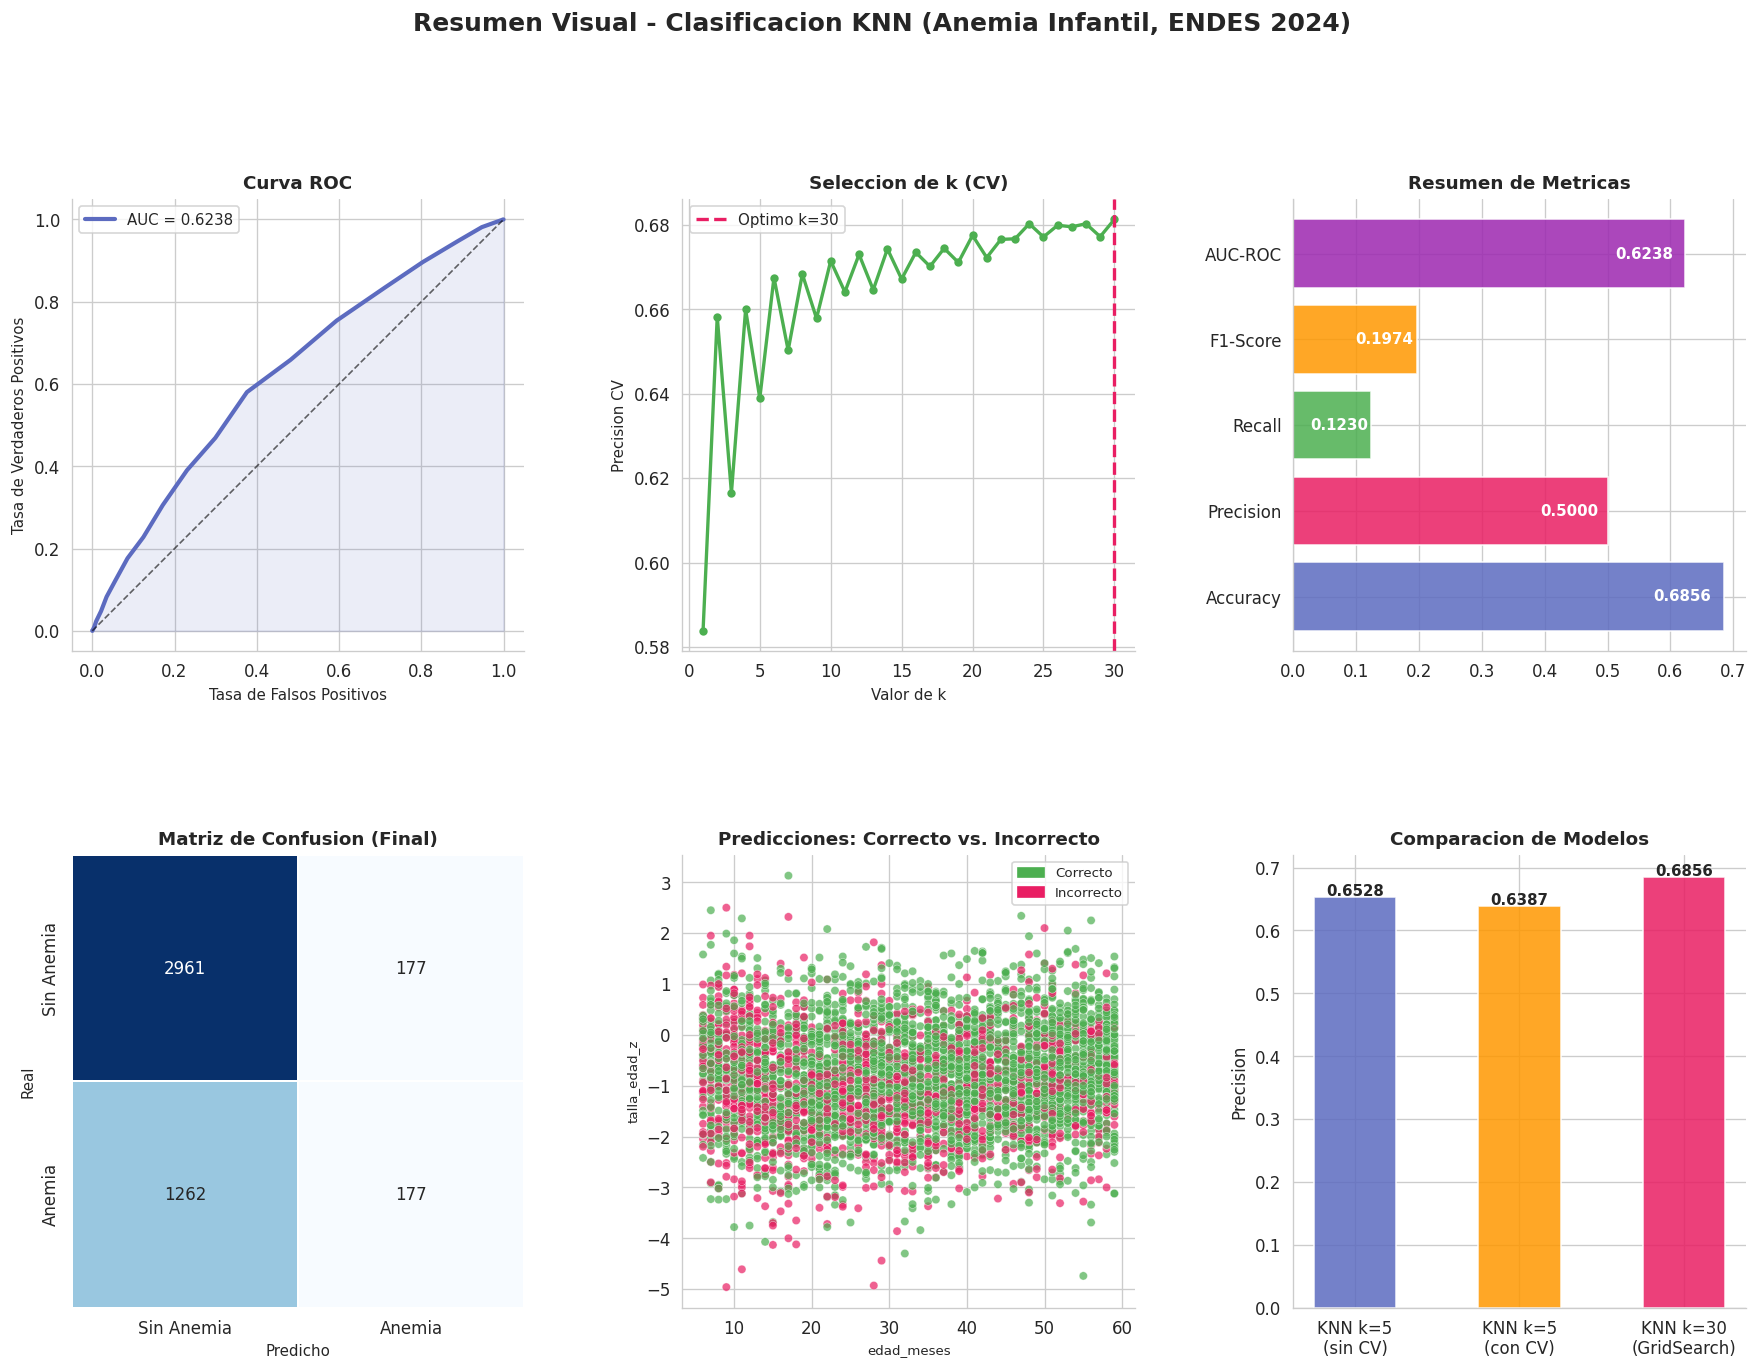

Grafico guardado: 16_resumen_visual.png


In [17]:
# =============================================================================
# 16. VISUALIZACION DE RESULTADOS FINALES
# =============================================================================
print(f"\n{SEPARADOR}")
print("  16. VISUALIZACION GENERAL DE RESULTADOS")
print(SEPARADOR)

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Resumen Visual - Clasificacion KNN (Anemia Infantil, ENDES 2024)',
             fontsize=15, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Grafico 1: Curva ROC ---
ax1 = fig.add_subplot(gs[0, 0])
y_prob = knn_final.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax1.plot(fpr, tpr, color='#5C6BC0', linewidth=2.5, label=f'AUC = {roc_auc:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6)
ax1.fill_between(fpr, tpr, alpha=0.12, color='#5C6BC0')
ax1.set_xlabel('Tasa de Falsos Positivos', fontsize=9)
ax1.set_ylabel('Tasa de Verdaderos Positivos', fontsize=9)
ax1.set_title('Curva ROC', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Grafico 2: Evolucion del k ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(k_range, cv_medias, 'o-', color='#4CAF50', linewidth=2, markersize=4)
ax2.axvline(mejor_k_cv, color='#E91E63', linewidth=2, linestyle='--',
            label=f'Optimo k={mejor_k_cv}')
ax2.set_xlabel('Valor de k', fontsize=9)
ax2.set_ylabel('Precision CV', fontsize=9)
ax2.set_title('Seleccion de k (CV)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Grafico 3: Resumen de metricas ---
ax3 = fig.add_subplot(gs[0, 2])
metricas_resumen = {
    'Accuracy'   : acc_final,
    'Precision'  : precision_score(y_test, y_pred_final),
    'Recall'     : recall_score(y_test, y_pred_final),
    'F1-Score'   : f1_score(y_test, y_pred_final),
    'AUC-ROC'    : roc_auc
}
colores_met = ['#5C6BC0', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']
bars = ax3.barh(list(metricas_resumen.keys()), list(metricas_resumen.values()),
                color=colores_met, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, metricas_resumen.values()):
    ax3.text(val * 0.97, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', ha='right', va='center',
             fontsize=9, fontweight='bold', color='white')
ax3.set_title('Resumen de Metricas', fontsize=11, fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- Grafico 4: Matriz de Confusion final ---
ax4 = fig.add_subplot(gs[1, 0])
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin Anemia', 'Anemia'],
            yticklabels=['Sin Anemia', 'Anemia'],
            ax=ax4, cbar=False, linewidths=1)
ax4.set_title('Matriz de Confusion (Final)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Real', fontsize=9)
ax4.set_xlabel('Predicho', fontsize=9)

# --- Grafico 5: Scatter top2 variables con predicciones ---
ax5 = fig.add_subplot(gs[1, 1])
colores_pred = np.where(y_pred_final == y_test.values, '#4CAF50', '#E91E63')
ax5.scatter(X_test[top2[0]], X_test[top2[1]], c=colores_pred,
            alpha=0.7, s=25, edgecolors='white', linewidth=0.3)
leyenda5 = [Patch(color='#4CAF50', label='Correcto'),
            Patch(color='#E91E63', label='Incorrecto')]
ax5.legend(handles=leyenda5, fontsize=8)
ax5.set_xlabel(top2[0], fontsize=8)
ax5.set_ylabel(top2[1], fontsize=8)
ax5.set_title('Predicciones: Correcto vs. Incorrecto', fontsize=11, fontweight='bold')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# --- Grafico 6: Comparacion modelos ---
ax6 = fig.add_subplot(gs[1, 2])
modelos  = ['KNN k=5\n(sin CV)', 'KNN k=5\n(con CV)', f'KNN k={mejor_k_cv}\n(GridSearch)']
accs     = [test_acc, cv_scores.mean(), acc_final]
colores6 = ['#5C6BC0', '#FF9800', '#E91E63']
bars6    = ax6.bar(modelos, accs, color=colores6, edgecolor='white',
                   linewidth=1, alpha=0.85, width=0.5)
for bar, val in zip(bars6, accs):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax6.set_title('Comparacion de Modelos', fontsize=11, fontweight='bold')
ax6.set_ylabel('Precision')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.savefig('16_resumen_visual.png', bbox_inches='tight')
plt.show()
print("Grafico guardado: 16_resumen_visual.png")


  17. PREDICCION CON NUEVOS VALORES

Nino     Diagnostico    P(Sin Anemia)    P(Anemia)      Confianza
-----------------------------------------------------------------
Nino 1    Sin Anemia      0.5333            0.4667         53.3%
Nino 2    Sin Anemia      0.7667            0.2333         76.7%
Nino 3    Sin Anemia      0.7000            0.3000         70.0%


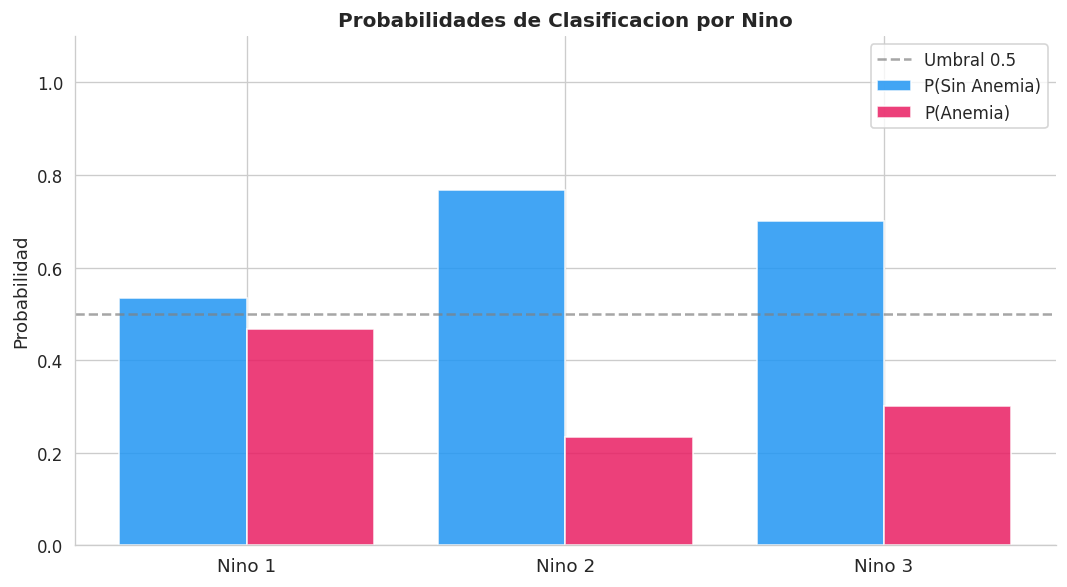

In [18]:
# =============================================================================
# 17. PREDICCION CON NUEVOS VALORES
# =============================================================================
print(f"\n{SEPARADOR}")
print("  17. PREDICCION CON NUEVOS VALORES")
print(SEPARADOR)

# Definimos 3 ninos hipoteticos con sus medidas antropometricas (Z-scores OMS)
nuevos_ninos = pd.DataFrame([
    {  # Nino 1: desnutricion cronica marcada -> mayor riesgo esperado de anemia
        'edad_meses': 12, 'talla_edad_z': -2.5, 'peso_edad_z': -2.0,
        'peso_talla_z': -1.0, 'imc_z': -1.0
    },
    {  # Nino 2: indicadores antropometricos normales -> menor riesgo esperado
        'edad_meses': 36, 'talla_edad_z': 0.2, 'peso_edad_z': 0.1,
        'peso_talla_z': 0.0, 'imc_z': 0.1
    },
    {  # Nino 3: caso intermedio
        'edad_meses': 24, 'talla_edad_z': -1.0, 'peso_edad_z': -0.5,
        'peso_talla_z': 0.0, 'imc_z': 0.0
    },
], columns=predictores)

nuevos_escalados = scaler.transform(nuevos_ninos)
predicciones     = knn_final.predict(nuevos_escalados)
probabilidades   = knn_final.predict_proba(nuevos_escalados)

print(f"\n{'Nino':<8} {'Diagnostico':<14} {'P(Sin Anemia)':<16} {'P(Anemia)':<14} {'Confianza'}")
print("-" * 65)

for i, (pred, prob) in enumerate(zip(predicciones, probabilidades)):
    diagnostico = 'Anemia' if pred == 1 else 'Sin Anemia'
    confianza   = max(prob) * 100
    print(f"Nino {i+1:<3}  {diagnostico:<14}  "
          f"{prob[0]:.4f}            {prob[1]:.4f}         {confianza:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
ninos_lbl = [f'Nino {i+1}' for i in range(len(nuevos_ninos))]
prob_sin  = [p[0] for p in probabilidades]
prob_con  = [p[1] for p in probabilidades]
x_pos = np.arange(len(ninos_lbl))

ax.bar(x_pos - 0.2, prob_sin, 0.4, label='P(Sin Anemia)', color=PALETTE[0], alpha=0.85, edgecolor='white')
ax.bar(x_pos + 0.2, prob_con, 0.4, label='P(Anemia)', color=PALETTE[1], alpha=0.85, edgecolor='white')
ax.axhline(0.5, color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='Umbral 0.5')
ax.set_xticks(x_pos)
ax.set_xticklabels(ninos_lbl, fontsize=11)
ax.set_ylim([0, 1.1])
ax.set_ylabel('Probabilidad', fontsize=11)
ax.set_title('Probabilidades de Clasificacion por Nino', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('17_predicciones_nuevos.png', bbox_inches='tight')
plt.show()

In [19]:
# =============================================================================
# 18. RESUMEN FINAL DEL PROCESO
# =============================================================================
print(f"\n{SEPARADOR}")
print("  18. RESUMEN EJECUTIVO DEL PROCESO")
print(SEPARADOR)

resumen = {
    "Dataset"                   : "ENDES 2024 - Modulo RECH6 (Anemia Infantil)",
    "Total de muestras"         : len(df),
    "Total de predictores"      : len(predictores),
    "Clases"                    : "Sin Anemia | Anemia",
    "Division Train/Test"       : "75% / 25%",
    "Escalado"                  : "MinMaxScaler",
    "k optimo encontrado"       : f"k = {grid_search.best_params_['n_neighbors']}",
    "Metrica de distancia"      : grid_search.best_params_['metric'],
    "Ponderacion"               : grid_search.best_params_['weights'],
    "Accuracy final"            : f"{acc_final:.4f} ({acc_final*100:.2f}%)",
    "AUC-ROC"                   : f"{roc_auc:.4f}",
    "F1-Score"                  : f"{f1_score(y_test, y_pred_final):.4f}",
    "Recall (Sensibilidad)"     : f"{recall_score(y_test, y_pred_final):.4f}",
    "Precision"                 : f"{precision_score(y_test, y_pred_final):.4f}",
}

print(f"\n{'Parametro':<35} {'Valor'}")
print("-" * 60)
for k, v in resumen.items():
    print(f"  {k:<33} {v}")

print(f"\n{SEPARADOR}")
print("  PROCESO COMPLETADO EXITOSAMENTE")
print(SEPARADOR)


  18. RESUMEN EJECUTIVO DEL PROCESO

Parametro                           Valor
------------------------------------------------------------
  Dataset                           ENDES 2024 - Modulo RECH6 (Anemia Infantil)
  Total de muestras                 18306
  Total de predictores              5
  Clases                            Sin Anemia | Anemia
  Division Train/Test               75% / 25%
  Escalado                          MinMaxScaler
  k optimo encontrado               k = 30
  Metrica de distancia              chebyshev
  Ponderacion                       uniform
  Accuracy final                    0.6856 (68.56%)
  AUC-ROC                           0.6238
  F1-Score                          0.1974
  Recall (Sensibilidad)             0.1230
  Precision                         0.5000

  PROCESO COMPLETADO EXITOSAMENTE
